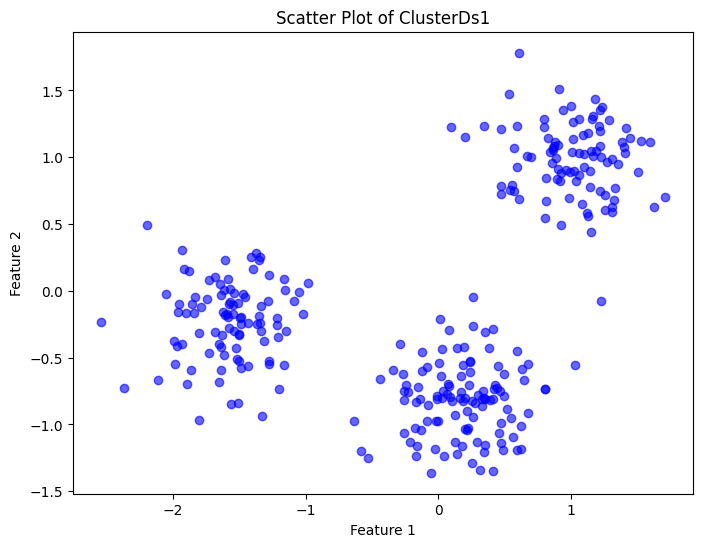

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

# Load the dataset
cluster_ds1 = pd.read_csv("ClusterDs1.csv")
cluster_ds2 = pd.read_csv("ClusterDs2.csv")
# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(cluster_ds1.iloc[:, 0], cluster_ds1.iloc[:, 1], color='blue', alpha=0.6)
plt.title("Scatter Plot of ClusterDs1")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


In [2]:
# 2.
# Explicitly set n_init to the default value of 10 to suppress the warning
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Fit the model to the data
kmeans.fit(cluster_ds1)



KMeans(n_clusters=3, n_init=10, random_state=42)

In [3]:
# 3
# Get the cluster labels
labels = kmeans.predict(cluster_ds1)

# Verify the labels
print(labels[:10])  # First 10 labels


[2 1 0 0 1 1 0 2 1 1]


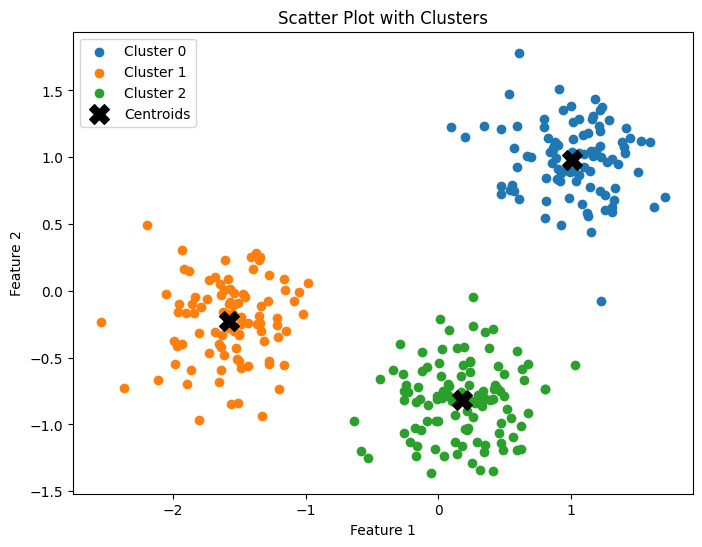

In [4]:
# 4
# Plot points with colors based on clusters
plt.figure(figsize=(8, 6))
for i in range(kmeans.n_clusters):
    cluster_points = cluster_ds1[labels == i]
    plt.scatter(cluster_points.iloc[:, 0], cluster_points.iloc[:, 1], label=f'Cluster {i}')

# Plot cluster centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title("Scatter Plot with Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()


In [5]:
# 5
# Ensure the feature names in the new DataFrame match the original DataFrame
cluster_ds2.columns = cluster_ds1.columns

# Predict using the DataFrame with matched feature names
predicted_labels = kmeans.predict(cluster_ds2)
print(predicted_labels[:10])  # First 10 predicted labels


[0 1 1 2 2 0 2 2 1 2]


In [6]:
# 6
# Extract centroids
centroids = kmeans.cluster_centers_

# Convert DataFrame to NumPy array for computation
data_points = cluster_ds2.to_numpy()

# Compute Euclidean distances for each point to each centroid
distances = np.sqrt(((data_points[:, np.newaxis, :] - centroids) ** 2).sum(axis=2))

# Create a DataFrame to store distances for verification
distance_df = pd.DataFrame(distances, columns=[f"centroid_{i}" for i in range(centroids.shape[0])])

# Display the first few rows of the distance DataFrame
print(distance_df.head())



   centroid_0  centroid_1  centroid_2
0    0.066933    2.798751    1.918028
1    2.922556    0.631391    2.331647
2    2.251192    0.608444    1.514235
3    1.704134    2.444539    0.648775
4    2.180490    2.400869    0.571265


In [7]:
#7.
# Find the index of the closest centroid for each data point
closest_centroids = distances.argmin(axis=1)

# Add the closest centroid index as a new column to the DataFrame
cluster_ds2['closest_centroid'] = closest_centroids

# Display the first few rows to verify the new column
print(cluster_ds2.head())



          0         1  closest_centroid
0  0.973851  0.929172                 0
1 -1.839089  0.348506                 1
2 -1.045098  0.072468                 1
3  0.820274 -0.710225                 2
4  0.633960 -1.164268                 2


In [8]:
# 8.

# Ensure predicted_labels and closest_centroid are NumPy arrays for comparison
predicted_labels = np.array(predicted_labels)
closest_centroids = cluster_ds2['closest_centroid'].to_numpy()

# Compare labels for equality
labels_match = np.array_equal(predicted_labels, closest_centroids)

# Print comparison result
if labels_match:
    print("The predicted cluster labels and closest centroid labels are identical.")
else:
    print("The predicted cluster labels and closest centroid labels are NOT identical.")
    
    # Find mismatched indices for debugging
    mismatches = np.where(predicted_labels != closest_centroids)[0]
    print(f"Mismatched indices: {mismatches}")
    print(f"First few mismatches: {predicted_labels[mismatches[:5]]} vs {closest_centroids[mismatches[:5]]}")


The predicted cluster labels and closest centroid labels are identical.
